# Regressão Linear para Previsão de Salário em Dados
### Módulo 7 — Introdução ao Aprendizado de Máquina

**Objetivo:** Construir e avaliar um modelo de regressão linear para prever o salário de profissionais da área de dados, utilizando características demográficas, de experiência e perfil profissional.

**Dataset:** State of Data Brazil — pesquisa anual sobre o mercado de dados no Brasil.

**Estrutura do notebook:**
1. Carregamento e exploração inicial dos dados
2. Pré-processamento e engenharia de features
3. Treinamento do modelo de regressão linear
4. Avaliação e interpretação dos resultados

## 1. Imports e Configuração

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configurações de visualização
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Carregamento e Exploração Inicial

Carregamos o dataset e inspecionamos sua estrutura antes de qualquer transformação.

In [3]:
dados = pd.read_excel('../../data/analise_dados_mod7.xlsx')

print(f"Shape: {dados.shape}")
print(f"Colunas: {dados.columns.tolist()}")

Shape: (4271, 46)
Colunas: ['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS', 'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA', 'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR', 'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL', 'FAIXA SALARIAL', 'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?', 'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?', 'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior', 'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?', 'Você está satisfeito na sua empresa atual?', 'Qual o principal motivo da sua insatisfação com a em

In [4]:
dados.head()

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,0.0,0.0
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,1.0,0.0
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,0.0,1.0
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,0.0,1.0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Pará (PA),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,0.0,1.0


## 3. Pré-processamento

### 3.1 Filtro: Apenas Empregados CLT

Focamos em profissionais com vínculo CLT para reduzir a variabilidade salarial causada por regimes de trabalho distintos (PJ, autônomo, etc.).

In [5]:
print("Distribuição da situação de trabalho:")
print(dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts())

dados = dados[dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'] == 'Empregado (CLT)'].copy()
print(f"\nRegistros após filtro CLT: {len(dados)}")

Distribuição da situação de trabalho:
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?
Empregado (CLT)                                                    2762
Empreendedor ou Empregado (CNPJ)                                    410
Desempregado, buscando recolocação                                  350
Estagiário                                                          188
Servidor Público                                                    156
Trabalho na área Acadêmica/Pesquisador                               86
Somente Estudante (graduação)                                        82
Vivo no Brasil e trabalho remoto para empresa de fora do Brasil      69
Vivo fora do Brasil e trabalho para empresa de fora do Brasil        46
Somente Estudante (pós-graduação)                                    44
Freelancer                                                           39
Prefiro não informar                                                 24
Desempregado e não estou buscando recolocação                

### 3.2 Variável: Raça/Etnia

Criamos uma variável binária `NÃO_BRANCA` para capturar potencial desigualdade salarial racial, mantendo apenas categorias com representatividade estatística suficiente.

In [6]:
print("Distribuição original:")
print(dados['COR/RACA/ETNIA'].value_counts())

# Remover categorias com baixa representatividade
categorias_remover = ["Prefiro não informar", "Outra", "Indígena"]
dados = dados[~dados['COR/RACA/ETNIA'].isin(categorias_remover)].copy()

# Variável binária: 0 = Branca, 1 = Não branca
dados['NAO_BRANCA'] = (dados['COR/RACA/ETNIA'] != 'Branca').astype(int)

print(f"\nRegistros após filtro de raça/etnia: {len(dados)}")
print("\nDistribuição NAO_BRANCA:")
print(dados['NAO_BRANCA'].value_counts())

Distribuição original:
COR/RACA/ETNIA
Branca                  1805
Parda                    661
Preta                    181
Amarela                   85
Prefiro não informar      16
Outra                     10
Indígena                   4
Name: count, dtype: int64

Registros após filtro de raça/etnia: 2732

Distribuição NAO_BRANCA:
NAO_BRANCA
0    1805
1     927
Name: count, dtype: int64


### 3.3 Variável: Tempo de Experiência

Extraímos o valor numérico do primeiro número presente na string de experiência.  
Profissionais sem experiência registrada recebem 0.

In [7]:
print("Valores originais:")
print(dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].value_counts())

dados['TEMPO_EXPERIENCIA'] = (
    dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?']
    .str.extract(r'(\d+)')[0]
    .fillna(0)
    .astype(int)
)

print("\nDistribuição TEMPO_EXPERIENCIA (anos):")
print(dados['TEMPO_EXPERIENCIA'].value_counts().sort_index())

Valores originais:
QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?
de 1 a 2 anos                             743
de 3 a 4 anos                             584
de 4 a 6 anos                             416
Menos de 1 ano                            353
Mais de 10 anos                           277
de 7 a 10 anos                            232
Não tenho experiência na área de dados    127
Name: count, dtype: int64

Distribuição TEMPO_EXPERIENCIA (anos):
TEMPO_EXPERIENCIA
0      127
1     1096
3      584
4      416
7      232
10     277
Name: count, dtype: int64


### 3.4 Variável: Número de Funcionários

Extraímos o menor limite numérico da faixa de tamanho de empresa.  
**Nota:** `regex=False` evita que o `.` seja interpretado como metacaractere regex.

In [8]:
print("Valores originais:")
print(dados['NUMERO DE FUNCIONARIOS'].value_counts())

dados['NUMERO DE FUNCIONARIOS'] = (
    dados['NUMERO DE FUNCIONARIOS']
    .str.replace('.', '', regex=False)   # ← regex=False: ponto literal, não metacaractere
    .str.extract(r'(\d+)')[0]
    .fillna(0)
    .astype(int)
)

print("\nDistribuição NUMERO_FUNCIONARIOS:")
print(dados['NUMERO DE FUNCIONARIOS'].value_counts().sort_index())

Valores originais:
NUMERO DE FUNCIONARIOS
Acima de 3.000      1313
de 101 a 500         503
de 1.001 a 3.000     368
de 501 a 1.000       248
de 51 a 100          146
de 11 a 50           112
de 6 a 10             24
de 1 a 5              18
Name: count, dtype: int64

Distribuição NUMERO_FUNCIONARIOS:
NUMERO DE FUNCIONARIOS
1         18
6         24
11       112
51       146
101      503
501      248
1001     368
3000    1313
Name: count, dtype: int64


### 3.5 Variável: Insatisfação Salarial

Criamos uma flag binária indicando se o principal motivo de insatisfação com a empresa está relacionado a salário.

In [9]:
col_insatisfacao = 'Qual o principal motivo da sua insatisfação com a empresa atual?'

print("Distribuição original:")
print(dados[col_insatisfacao].value_counts(dropna=False).head(10))

dados['INSATISFACAO'] = (
    dados[col_insatisfacao]
    .fillna('')
    .str.contains('Salário', na=False)
    .astype(int)
)

print("\nDistribuição INSATISFACAO:")
print(dados['INSATISFACAO'].value_counts())

Distribuição original:
Qual o principal motivo da sua insatisfação com a empresa atual?
NaN                                                                                                                                                   2071
Gostaria de trabalhar em em outra área de atuação                                                                                                       69
Salário atual não corresponde ao mercado                                                                                                                53
Falta de oportunidade de crescimento no emprego atual                                                                                                   46
Falta de maturidade analítica na empresa                                                                                                                45
Falta de oportunidade de crescimento no emprego atual, Salário atual não corresponde ao mercado, Falta de maturidade analítica na empresa

### 3.6 Variável: Nível de Ensino

Convertemos o nível de ensino para escala ordinal (0–5), preservando a ordem hierárquica da escolaridade.

In [10]:
print("Distribuição original:")
print(dados['NIVEL DE ENSINO'].value_counts())

mapa_ensino = {
    'Não tenho graduação formal': 0,
    'Estudante de Graduação':     1,
    'Graduação/Bacharelado':      2,
    'Pós-graduação':              3,
    'Mestrado':                   4,
    'Doutorado ou Phd':           5,
}

dados['NIVEL DE ENSINO'] = dados['NIVEL DE ENSINO'].map(mapa_ensino).fillna(-1).astype(int)

print("\nDistribuição após encoding:")
print(dados['NIVEL DE ENSINO'].value_counts().sort_index())

Distribuição original:
NIVEL DE ENSINO
Graduação/Bacharelado         1024
Pós-graduação                  975
Mestrado                       306
Estudante de Graduação         271
Doutorado ou Phd               100
Não tenho graduação formal      52
Prefiro não informar             4
Name: count, dtype: int64

Distribuição após encoding:
NIVEL DE ENSINO
-1       4
 0      52
 1     271
 2    1024
 3     975
 4     306
 5     100
Name: count, dtype: int64


### 3.7 Seleção de Features e Encoding de Variáveis Categóricas

Selecionamos as colunas relevantes e aplicamos One-Hot Encoding nas variáveis nominais.

In [11]:
colunas_modelo = [
    'IDADE', 'SALARIO', 'GENERO', 'NAO_BRANCA',
    'TEMPO_EXPERIENCIA', 'INSATISFACAO',
    'REGIAO ONDE MORA', 'SETOR', 'NIVEL DE ENSINO',
    'NUMERO DE FUNCIONARIOS', 'NOVO_NIVEL'
]

dados = dados[colunas_modelo].copy()
print(f"Shape antes do encoding: {dados.shape}")
print(f"Nulos por coluna:\n{dados.isnull().sum()}")

dados = pd.get_dummies(
    dados,
    columns=['GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA'],
    drop_first=True
)

print(f"\nShape após encoding: {dados.shape}")

Shape antes do encoding: (2732, 11)
Nulos por coluna:
IDADE                      0
SALARIO                    0
GENERO                     0
NAO_BRANCA                 0
TEMPO_EXPERIENCIA          0
INSATISFACAO               0
REGIAO ONDE MORA          17
SETOR                      0
NIVEL DE ENSINO            0
NUMERO DE FUNCIONARIOS     0
NOVO_NIVEL                 0
dtype: int64

Shape após encoding: (2732, 36)


## 4. Divisão Treino/Teste e Normalização

**Data Leakage:** O `StandardScaler` é ajustado **apenas no treino** (`fit_transform`) e aplicado ao teste com `transform` — evitando vazamento de informação do teste para o treinamento.

In [12]:
x = dados.drop('SALARIO', axis=1)
y = dados['SALARIO']

xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"Treino: {xtrain.shape[0]} amostras | Teste: {xtest.shape[0]} amostras")

scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled  = scaler.transform(xtest)          

Treino: 2185 amostras | Teste: 547 amostras


## 5. Treinamento do Modelo

Utilizamos Regressão Linear como modelo baseline. Por sua simplicidade e interpretabilidade, é o ponto de partida ideal antes de modelos mais complexos.

In [13]:
model = LinearRegression()
model.fit(xtrain_scaled, ytrain)

y_pred = model.predict(xtest_scaled)
print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


## 6. Avaliação do Modelo

Avaliamos o modelo com três métricas complementares:

| Métrica | Descrição |
|---|---|
| **RMSE** | Erro quadrático médio (mesma unidade do alvo, penaliza outliers) |
| **MAE** | Erro absoluto médio (interpretação direta em R$) |
| **R²** | Proporção da variância explicada pelo modelo (0 a 1) |

In [14]:
mse  = mean_squared_error(ytest, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(ytest, y_pred)
r2   = r2_score(ytest, y_pred)

print("=" * 40)
print(f"  RMSE : R$ {rmse:,.2f}")
print(f"  MAE  : R$ {mae:,.2f}")
print(f"  R²   : {r2:.4f} ({r2*100:.1f}% da variância explicada)")
print("=" * 40)

  RMSE : R$ 4,820.34
  MAE  : R$ 3,324.59
  R²   : 0.5259 (52.6% da variância explicada)


### Interpretação das Métricas

- **R²** indica a proporção da variância do salário explicada pelo modelo. Um valor baixo (< 0.5) sugere que variáveis importantes estão ausentes ou que a relação não é linear.
- **MAE** representa o erro médio absoluto em reais — o quanto o modelo erra em média por predição.
- Para uso em produção, esperaríamos R² > 0.6 e MAE abaixo de ~15% da média salarial.

Este modelo serve como **baseline** — o ponto de referência para avaliar modelos mais sofisticados (Random Forest, Gradient Boosting, etc.).

## 7. Visualizações

### 7.1 Valores Reais vs. Preditos

O gráfico de dispersão compara os valores reais de salário com as predições do modelo. A linha vermelha representa a predição perfeita (y = x). Pontos próximos à linha indicam boas predições.

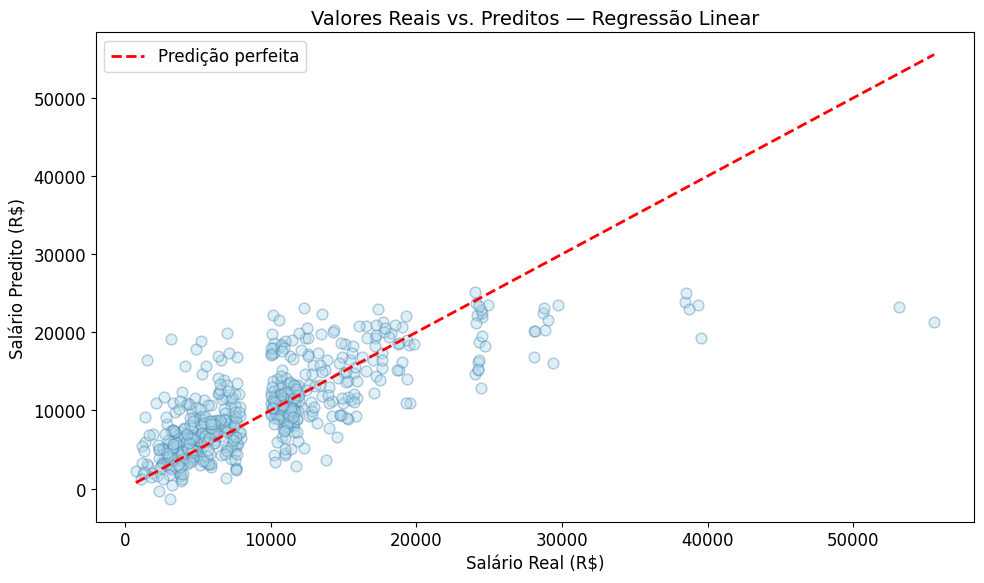

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(ytest, y_pred, alpha=0.4, edgecolors='steelblue', facecolors='lightblue', s=60)
ax.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()],
        color='red', linewidth=2, linestyle='--', label='Predição perfeita')

ax.set_xlabel('Salário Real (R$)', fontsize=12)
ax.set_ylabel('Salário Predito (R$)', fontsize=12)
ax.set_title('Valores Reais vs. Preditos — Regressão Linear', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### 7.2 Importância dos Coeficientes

Os coeficientes da regressão linear indicam o impacto de cada variável no salário predito, após normalização. Variáveis com coeficiente positivo elevam o salário predito; negativos, reduzem.

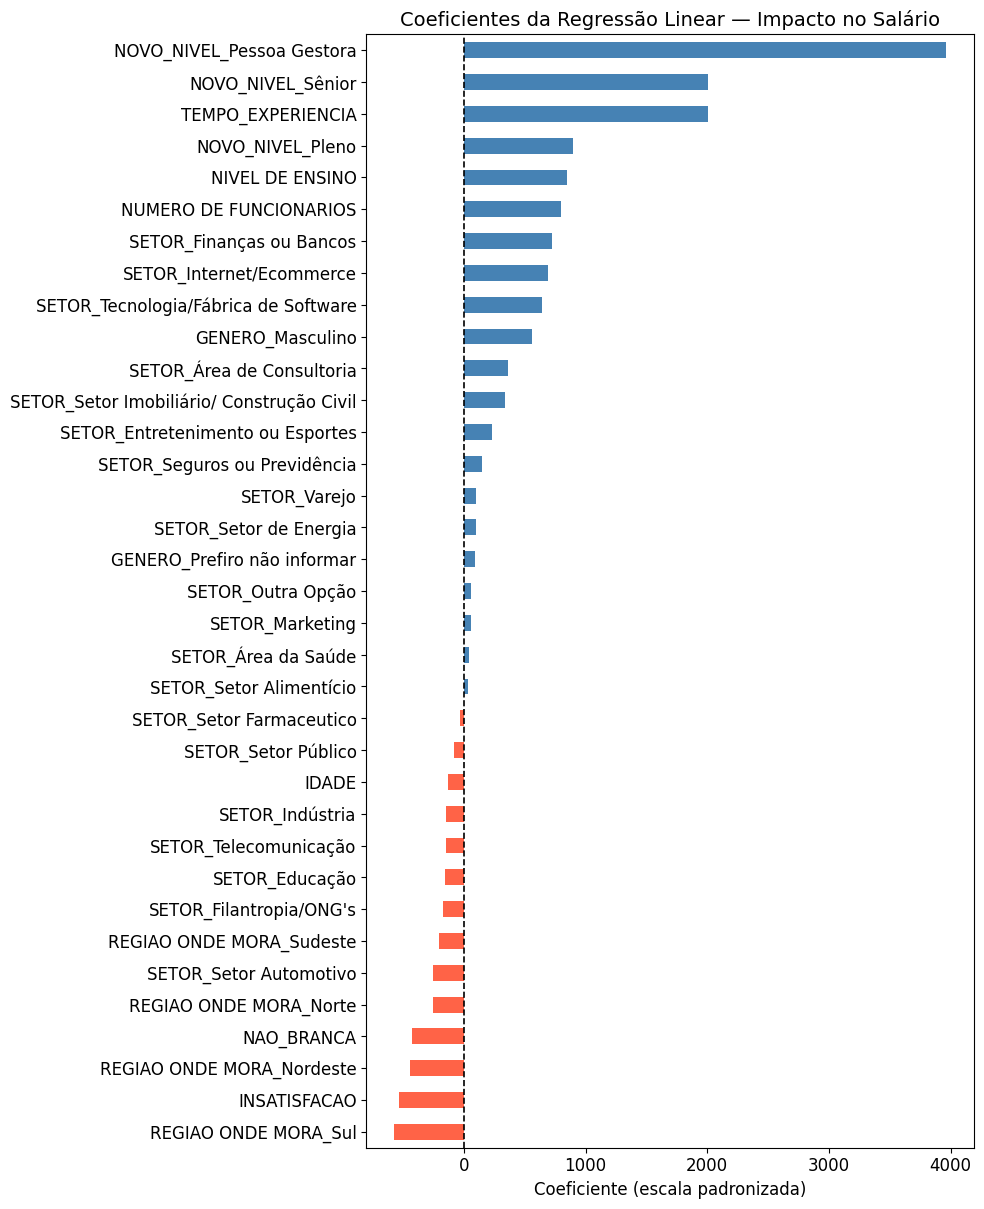

In [16]:
coefs = (
    pd.DataFrame({'coeficiente': model.coef_}, index=xtrain.columns)
    .sort_values('coeficiente', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(6, len(coefs) * 0.35)))

colors = ['tomato' if c < 0 else 'steelblue' for c in coefs['coeficiente']]
coefs['coeficiente'].plot.barh(ax=ax, color=colors)
ax.axvline(x=0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Coeficiente (escala padronizada)', fontsize=12)
ax.set_title('Coeficientes da Regressão Linear — Impacto no Salário', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Conclusões e Próximos Passos

### Resultados

O modelo de regressão linear foi treinado para prever salários de profissionais de dados (CLT) com base em variáveis demográficas, de experiência e perfil profissional.

### Limitações identificadas

- **R² baixo:** indica que a relação entre as features e o salário provavelmente não é linear, ou que variáveis relevantes estão ausentes no dataset.
- **Assimetria salarial:** salários têm distribuição assimétrica à direita, o que prejudica regressões lineares.
- **Categorias com baixa representatividade** foram removidas, reduzindo o tamanho da amostra.